# Lab 03: Edge Detection Techniques and Classification


In [1]:
import os, time, copy, glob
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from skimage.util import random_noise
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cuda


In [5]:
from pathlib import Path

In [6]:
# Dataset Loading
meta_paths = glob.glob("/kaggle/input/**/HAM10000_metadata.csv", recursive=True)
if meta_paths:
    df = pd.read_csv(meta_paths[0])
    image_map = {Path(f).stem: str(Path(root) / f) for root, _, files in os.walk("/kaggle/input") for f in files if f.endswith(('.jpg','.png'))}
    df['image_path'] = df['image_id'].map(image_map)
    df = df.dropna(subset=['image_path']).reset_index(drop=True)
else:
    print("Metadata not found. Please attach the dataset.")


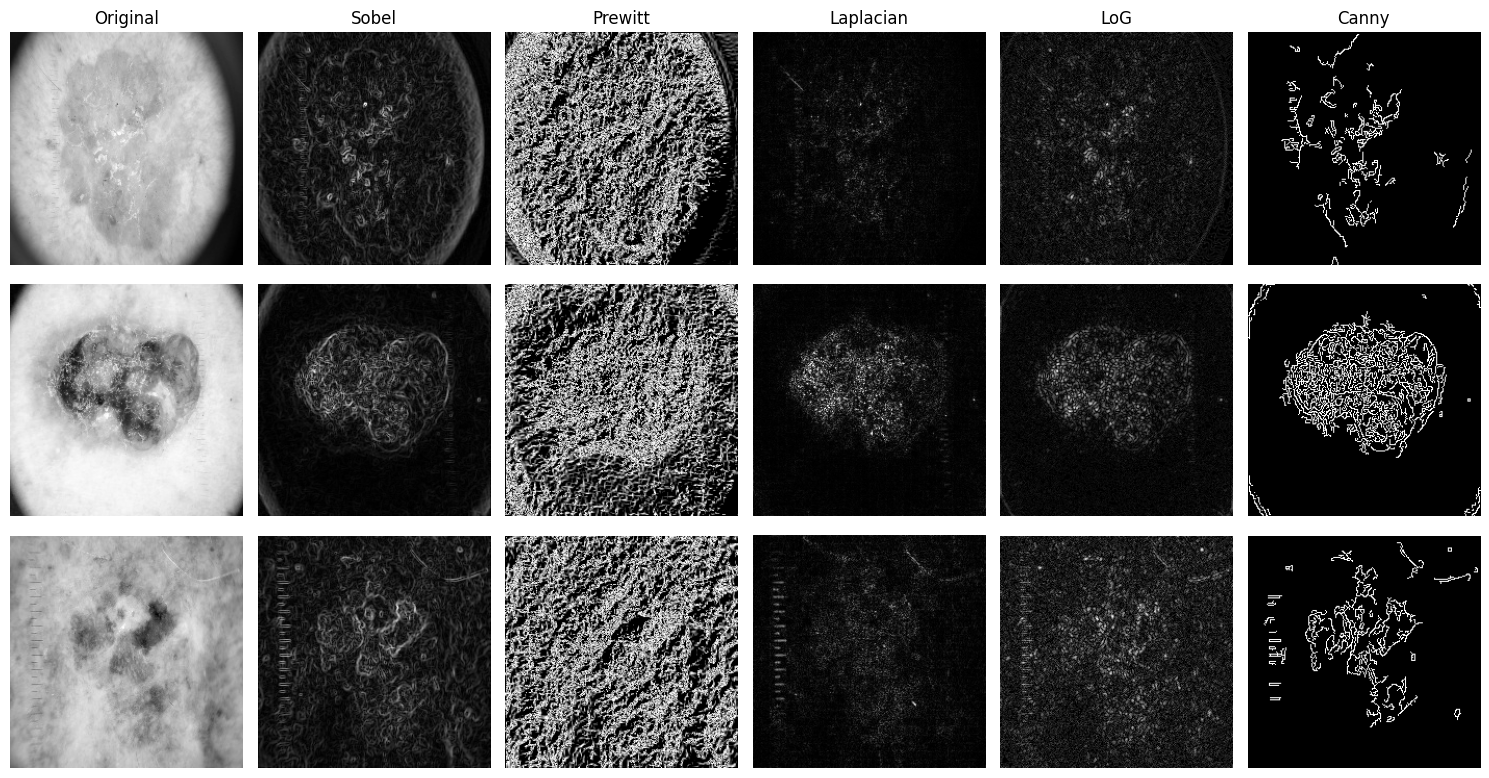

In [7]:
# Task 1: Comparative Edge Detection
def apply_edges(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel_mag = np.uint8(255 * np.sqrt(sobel_x**2 + sobel_y**2) / np.max(np.sqrt(sobel_x**2 + sobel_y**2)))
    
    kx, ky = np.array([[-1,0,1],[-1,0,1],[-1,0,1]]), np.array([[-1,-1,-1],[0,0,0],[1,1,1]])
    prewitt = np.uint8(np.clip(np.sqrt(cv2.filter2D(gray, -1, kx)**2 + cv2.filter2D(gray, -1, ky)**2), 0, 255))
    
    laplacian = cv2.convertScaleAbs(cv2.Laplacian(gray, cv2.CV_64F))
    log = cv2.convertScaleAbs(cv2.Laplacian(cv2.GaussianBlur(gray, (5,5), 0), cv2.CV_64F))
    canny = cv2.Canny(gray, 50, 150)
    
    return gray, sobel_mag, prewitt, laplacian, log, canny

if 'df' in locals():
    sample_imgs = df.groupby('dx').first().head(3)['image_path'].tolist()
    fig, axes = plt.subplots(3, 6, figsize=(15, 8))
    titles = ["Original", "Sobel", "Prewitt", "Laplacian", "LoG", "Canny"]
    
    for i, path in enumerate(sample_imgs):
        img = np.array(Image.open(path).resize((224, 224)))
        images = apply_edges(img)
        for j, (ax, res, title) in enumerate(zip(axes[i], images, titles)):
            ax.imshow(res, cmap='gray'); ax.axis('off')
            if i == 0: ax.set_title(title)
    plt.tight_layout(); plt.show()


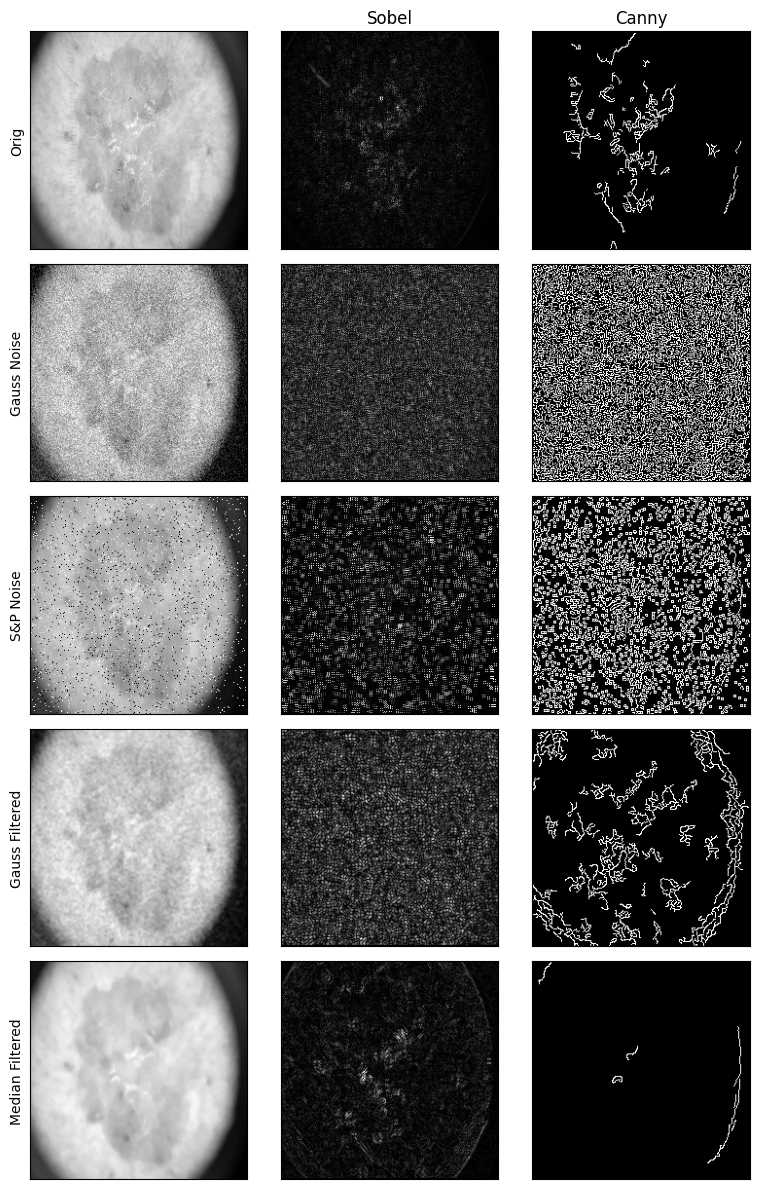

In [8]:
# Task 2: Effect of Noise on Edge Detection
if 'df' in locals():
    gray = cv2.cvtColor(np.array(Image.open(sample_imgs[0]).resize((224, 224))), cv2.COLOR_RGB2GRAY)
    n_gauss = np.uint8(255 * random_noise(gray, mode='gaussian', var=0.01))
    n_sp = np.uint8(255 * random_noise(gray, mode='s&p', amount=0.05))
    g_filt = cv2.GaussianBlur(n_gauss, (5,5), 0)
    m_filt = cv2.medianBlur(n_sp, 5)
    
    tests = [("Orig", gray), ("Gauss Noise", n_gauss), ("S&P Noise", n_sp), 
             ("Gauss Filtered", g_filt), ("Median Filtered", m_filt)]
             
    fig, axes = plt.subplots(5, 3, figsize=(8, 12))
    for i, (name, imp) in enumerate(tests):
        s = cv2.convertScaleAbs(cv2.Sobel(imp, cv2.CV_64F, 1, 1, ksize=3))
        c = cv2.Canny(imp, 50, 150)
        axes[i,0].imshow(imp, cmap='gray'); axes[i,0].set_ylabel(name)
        axes[i,1].imshow(s, cmap='gray'); axes[i,1].set_title("Sobel" if i==0 else "")
        axes[i,2].imshow(c, cmap='gray'); axes[i,2].set_title("Canny" if i==0 else "")
        for ax in axes[i]: ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.show()


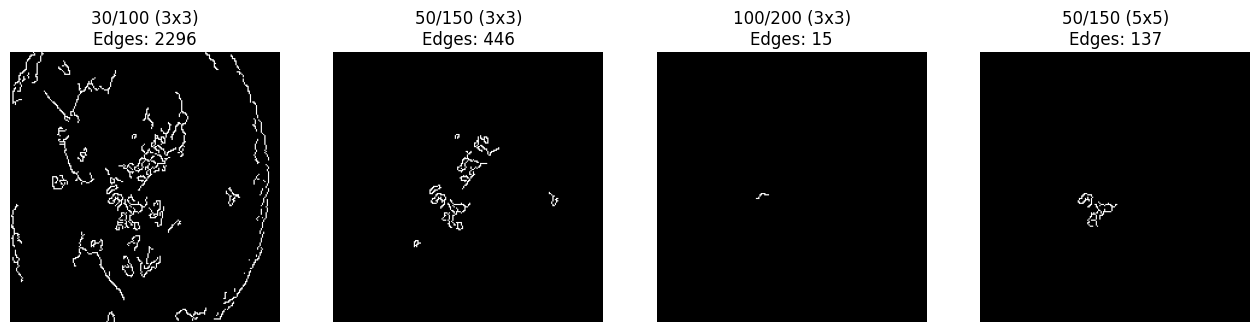

In [9]:
# Task 3: Parameter Analysis of Canny
if 'df' in locals():
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    configs = [("30/100 (3x3)", 30, 100, 3), ("50/150 (3x3)", 50, 150, 3), 
               ("100/200 (3x3)", 100, 200, 3), ("50/150 (5x5)", 50, 150, 5)]
    
    for ax, (title, low, high, k) in zip(axes, configs):
        blurred = cv2.GaussianBlur(gray, (k, k), 0)
        c = cv2.Canny(blurred, low, high)
        ax.imshow(c, cmap='gray'); ax.axis('off')
        ax.set_title(f"{title}\nEdges: {np.count_nonzero(c)}")
    plt.show()


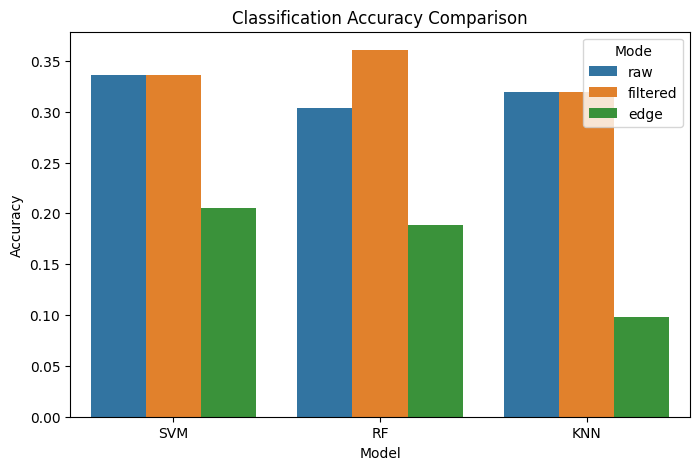

In [10]:
# Task 4 & 5 & 6: Classification (SVM, RF, KNN) on Raw, Filtered, Edge
if 'df' in locals():
    sub_df = df.groupby('dx').sample(n=100, replace=True).drop_duplicates()
    X_p, y = sub_df['image_path'].values, sub_df['dx'].astype('category').cat.codes.values
    X_tr, X_te, y_tr, y_te = train_test_split(X_p, y, test_size=0.2, random_state=42)
    
    def get_data(paths, mode):
        data = []
        for p in paths:
            i = cv2.resize(cv2.imread(p), (64, 64))
            if mode == 'raw': r = cv2.cvtColor(i, cv2.COLOR_BGR2RGB)
            elif mode == 'filtered': r = cv2.GaussianBlur(cv2.cvtColor(i, cv2.COLOR_BGR2RGB), (5,5), 0)
            elif mode == 'edge': r = np.stack([cv2.Canny(cv2.cvtColor(i, cv2.COLOR_BGR2GRAY), 50, 150)]*3, axis=-1)
            data.append(r.flatten())
        return np.array(data)

    results = []
    models = {"SVM": SVC(), "RF": RandomForestClassifier(n_estimators=50), "KNN": KNeighborsClassifier()}
    
    for mode in ['raw', 'filtered', 'edge']:
        Xt, Xv = get_data(X_tr, mode), get_data(X_te, mode)
        for name, clf in models.items():
            t0 = time.time(); clf.fit(Xt, y_tr); t_tr = time.time()-t0
            t0 = time.time(); preds = clf.predict(Xv); t_in = time.time()-t0
            acc = accuracy_score(y_te, preds)
            results.append({"Model": name, "Mode": mode, "Accuracy": acc, "Train(s)": t_tr, "Inf(s)": t_in})
            
    res_df = pd.DataFrame(results)
    
    plt.figure(figsize=(8, 5))
    sns.barplot(data=res_df, x='Model', y='Accuracy', hue='Mode')
    plt.title("Classification Accuracy Comparison")
    plt.show()


## Deliverables and Questions
(Fill out Tables 1, 2, 3 and answer the 7 Discussion Questions in your report based on the outputs above).
